In [17]:
import glob
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import torch

from cryosim import rotations
from cryosim.image_tools import normalize_particles
from cryosim.pdbtools import PDB
from cryosim.plotting_tools import plot3d
from cryosim.potential import PotentialBuilder

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Create 3D scattering potential

In [2]:
# fetch pdb file
pdb_code = "6bdf"
assembly = True  # True: fetches assembly. False: fetches subunit. int: fetches specific assembly #int
pdb = PDB(pdb_code, assembly=True, savefolder="../pdb-data/")

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6bdf-assembly1.cif, skip fetching.


Output()

In [3]:
# Samples 3D scattering potential onto specified grid
n = 256  # number of pixels per axis
dx = 1  # angstrom, pixel size.
device = "cpu"
pb = PotentialBuilder(n, dx, pdb.atomic_numbers, pdb.coordinates).to(device)

In [4]:
with torch.no_grad():
    V = pb(pdb.coordinates).clone()

Output()

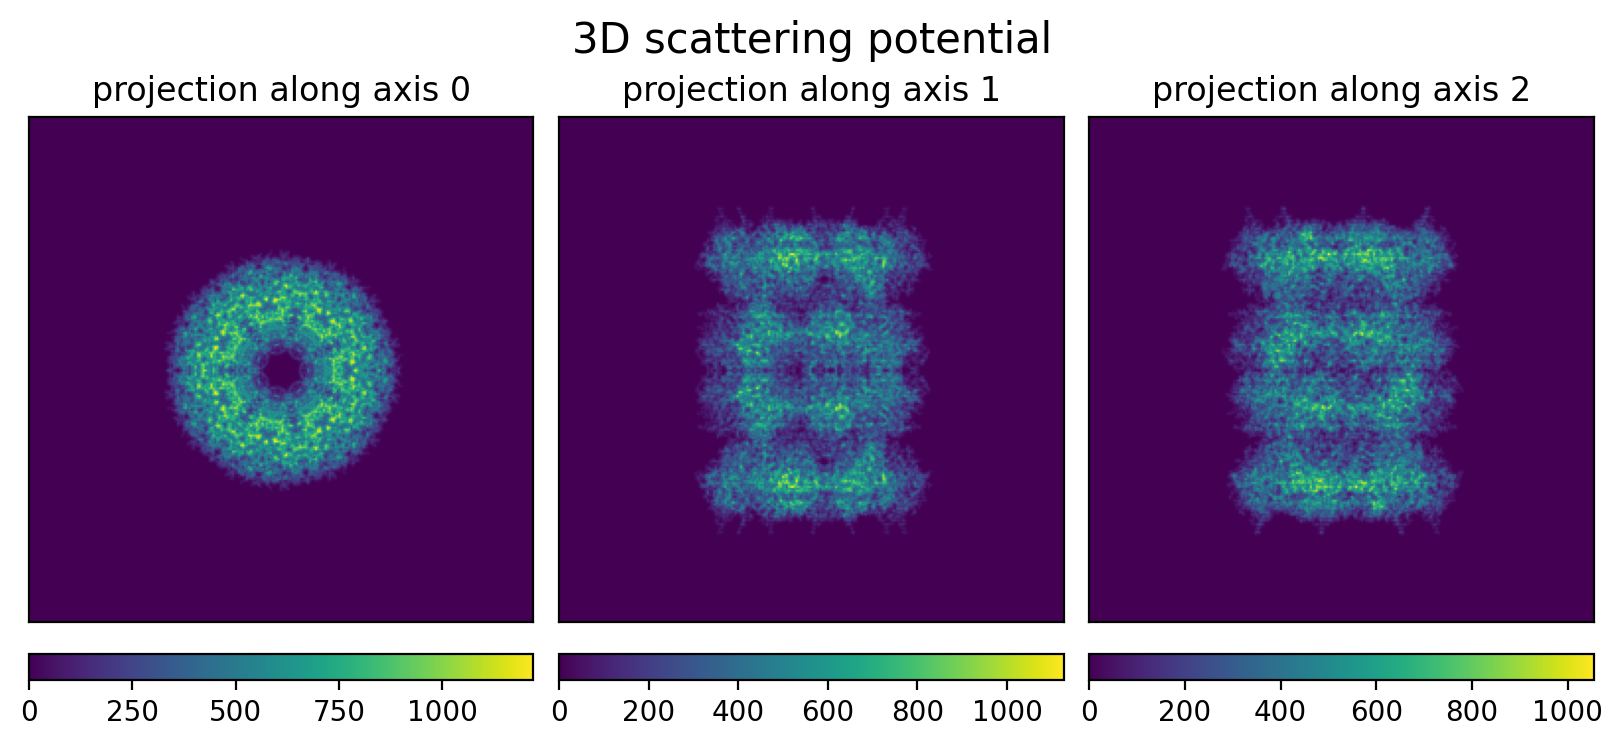

In [5]:
plot3d(V, title="3D scattering potential")

## Generate dataset
Here, you can choose to either use random or in-plane rotations, and random or fixed defocus values (comment/uncomment respectively).

In [6]:
n_particles = 3000
energy = 300  # keV
dose_per_angstrom = 20  # e-/A^2
Cs = 2e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1

In [7]:
# random quaternions
quaternions = rotations.random_quaternion(n_particles)
quaternions.shape

torch.Size([3000, 4])

In [8]:
# random defocus
defocus_min = 5000  # angstrom
defocus_max = 15000  # angstrom
defocus_A = torch.rand(n_particles) * (defocus_max - defocus_min) + defocus_min


# Can include 'cs', 'dfu', 'dfv', 'dfang', 'tiltx', 'tilty', 'phaseshift', 'trefoil1, 'trefoil2'
ctf_params = {
    "cs": torch.tensor([Cs] * n_particles),
    "dfu": defocus_A,
}

In [9]:
# random shift. set to 0 for no shifts
shift = 2  # A
rlnOriginXAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
rlnOriginYAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
translations = torch.stack([rlnOriginXAngst, rlnOriginYAngst], dim=-1)
translations.shape

torch.Size([3000, 2])

In [10]:
# save parameters
torch.save(quaternions, "../cache/quaternions.pt")
torch.save(translations, "../cache/translations.pt")
torch.save(ctf_params, "../cache/ctf_params.pt")
torch.save(V, "../cache/V.pt")

In [11]:
# Use multislice, holography, poisson and random_choice to obtain close to experimental conditions.
scattering_model = "multislice"  # 'multislice', 'firstborn', 'projection', 'ctf'
aberration_model = "holography"  # 'holography' or 'ctf'

noise_model = "poisson"  # 'poisson' or None
# noise_model = None

ice_model = "iterative"  # 'randomchoice' for fast & inaccurate, 'iterative' for slow & accurate, or None
# ice_model = None

ice_thickness = 0  # angstroms, set to 0 for minimum ice thickness = particle box size

crowd_min_distance = pdb.max_diameter  # angstroms, set to None for no crowding
# crowd_min_distance = None

# pad_fft = False # True to avoid edge artifacts when if crowd_min_distance is not None
pad_fft = "True"

In [20]:
output_path = "../cache/images.pt"
cmd = [
    "python",
    "../src/cryosim/simulate_particles.py",
    "--V_path",
    "../cache/V.pt",
    "--dx",
    f"{dx}",
    "--quaternions_path",
    "../cache/quaternions.pt",
    "--translations_path",
    "../cache/translations.pt",
    "--ctf_params_path",
    "../cache/ctf_params.pt",
    "--energy",
    f"{energy}",
    "--dose_per_angstrom",
    f"{dose_per_angstrom}",
    "--n_particles",
    f"{n_particles}",
    "--batch_size",
    "5",
    "--scattering_model",
    scattering_model,
    "--aberration_model",
    aberration_model,
    "--noise_model",
    noise_model,
    "--ice_model",
    ice_model,
    "--ice_thickness",
    f"{ice_thickness}",
    "--alpha",
    f"{alpha}",
    "--crowd_min_distance",
    f"{crowd_min_distance}",
    "--pad_fft",
    pad_fft,
    "--devices",
    "0,1,2",  # cuda ids
    "--output_path",
    output_path,
]

joined = " ".join(cmd)
print("Execute this command in terminal:\n" + joined)


process = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,  # line-buffered
)

# Print output in real time, preserving \r
while True:
    output = process.stdout.read(1)  # read one character at a time
    if output == "" and process.poll() is not None:
        break
    if output:
        sys.stdout.write(output)
        sys.stdout.flush()

Execute this command in terminal:
python ../src/cryosim/simulate_particles.py --V_path ../cache/V.pt --dx 1 --quaternions_path ../cache/quaternions.pt --translations_path ../cache/translations.pt --ctf_params_path ../cache/ctf_params.pt --energy 300 --dose_per_angstrom 20 --n_particles 3000 --batch_size 5 --scattering_model multislice --aberration_model holography --noise_model poisson --ice_model iterative --ice_thickness 0 --alpha 0.1 --crowd_min_distance 191.70848127367987 --pad_fft True --devices 0,1,2 --output_path ../cache/images.pt


In [21]:
output_dir = os.path.dirname(output_path)

## Clean up data
# find all predictions and batch index files
prediction_files = sorted(glob.glob(os.path.join(output_dir, "predictions_*.pt")))
index_files = sorted(glob.glob(os.path.join(output_dir, "batch_indices_*.pt")))

all_preds = []
all_indices = []

for p_file, i_file in zip(prediction_files, index_files):
    preds = torch.load(p_file)  # [batch_size, H, W] or similar
    indices = torch.load(i_file)  # [batch_size]
    all_preds.append(preds)
    all_indices.append(indices)

# concatenate all predictions and indices
all_preds = torch.cat(all_preds, dim=0)
all_indices = torch.cat(all_indices, dim=0)

# sort predictions according to original batch indices
sorted_order = torch.argsort(all_indices)
images = all_preds[sorted_order]

# save final ordered predictions
torch.save(images, output_path)
print(f"Saved all {images.shape[0]} images to images.pt")

# delete intermediate files
for f in prediction_files + index_files:
    os.remove(f)

In [ ]:
images.shape

In [ ]:
fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(images[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params[i, 2] / 10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()

In [ ]:
# normalize and flip sign
particles, means, stds = normalize_particles(images)
particles = -particles

fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(particles[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params[i, 2] / 10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()

In [ ]:
# change folder paths for your use.
# folderpath='/scratch/loh/joel/5MAC/simulated_data/'
# filename = '3000_256x256_20dose_nocrowd_and_ice_16sep2025'
# create_particle_starfile(
#     particles,
#     rotations=quaternions,
#     translations=translations,
#     ctf_params=ctf_params,
#     dx=dx,
#     energy=energy,
#     alpha=alpha,
#     starfilename=filename,
#     folderpath=folderpath
# )